DATASET INFORMATION
Total PET Images : 1699
Training Images   : 1189
Validation Images : 255
Testing Images    : 255


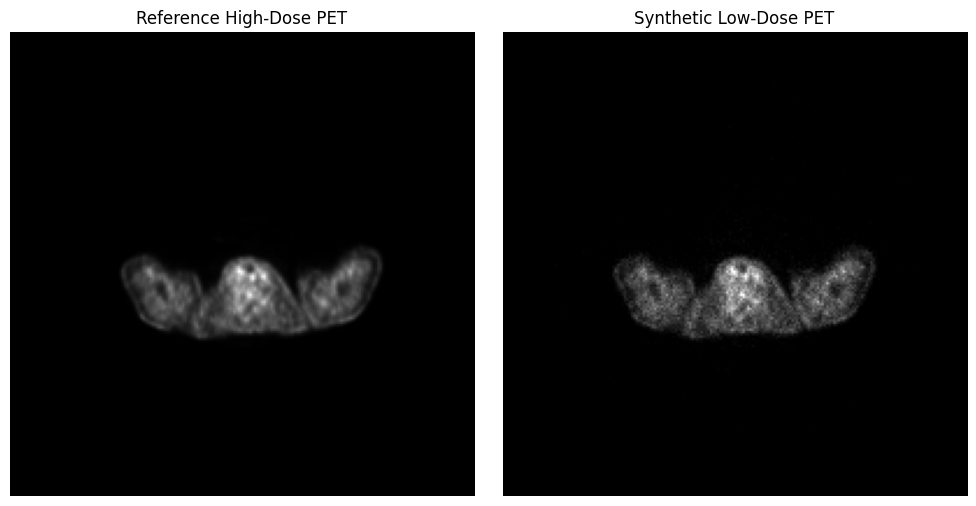

In [1]:

###### CELL 1



# =====================================================
# STEP 1: IMPORT LIBRARIES
# =====================================================

import os
import numpy as np
import pydicom
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# =====================================================
# STEP 2: SET RANDOM SEED
# =====================================================

np.random.seed(42)
torch.manual_seed(42)

# =====================================================
# STEP 3: DEFINE DATASET PATH
# =====================================================

DATA_DIR = "/kaggle/input/datasets/skarthik112/pet-image"

# =====================================================
# STEP 4: READ ALL DICOM FILES
# =====================================================

files = sorted([
    os.path.join(DATA_DIR, f)
    for f in os.listdir(DATA_DIR)
    if f.endswith(".dcm")
])

print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)
print("Total PET Images :", len(files))

# =====================================================
# STEP 5: TRAIN / VALIDATION / TEST SPLIT (70/15/15)
# =====================================================

train_files, temp_files = train_test_split(
    files,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

val_files, test_files = train_test_split(
    temp_files,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print(f"Training Images   : {len(train_files)}")
print(f"Validation Images : {len(val_files)}")
print(f"Testing Images    : {len(test_files)}")

# =====================================================
# STEP 6: LOAD PET IMAGE
# =====================================================

def load_pet(path):
    """
    Load DICOM PET image and normalize to [0,1].
    """
    ds = pydicom.dcmread(path)

    img = ds.pixel_array.astype(np.float32)

    img = img - img.min()
    img = img / (img.max() + 1e-8)

    return img

# =====================================================
# STEP 7: GENERATE SYNTHETIC LOW-DOSE PET
# =====================================================

def simulate_low_dose(img, reduction_factor=10):
    """
    Generate synthetic low-dose PET using Poisson noise.

    reduction_factor:
        4  -> Mild degradation
        10 -> Recommended
        20 -> Heavy degradation
    """

    img = img.astype(np.float32)
    img = img / (img.max() + 1e-8)

    counts = img * 1000.0
    counts = counts / reduction_factor

    noisy_counts = np.random.poisson(counts)

    low_img = noisy_counts / (1000.0 / reduction_factor)
    low_img = np.clip(low_img, 0, 1)

    return low_img

# =====================================================
# STEP 8: VISUALIZE SAMPLE IMAGE
# =====================================================

sample_high = load_pet(train_files[0])
sample_low = simulate_low_dose(sample_high, reduction_factor=10)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(sample_high, cmap="gray")
plt.title("Reference High-Dose PET")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sample_low, cmap="gray")
plt.title("Synthetic Low-Dose PET")
plt.axis("off")

plt.tight_layout()
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 99.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.

2026-07-01 05:13:43.687633: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782882824.106565      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782882824.214158      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782882825.316336      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782882825.316379      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782882825.316382      23 computation_placer.cc:177] computation placer alr

DATASET SUMMARY
Training Samples   : 1189
Validation Samples : 255
Testing Samples    : 255

✅ DataLoaders created successfully!

Batch Shapes
Low Dose  : torch.Size([4, 1, 200, 200])
High Dose : torch.Size([4, 1, 200, 200])


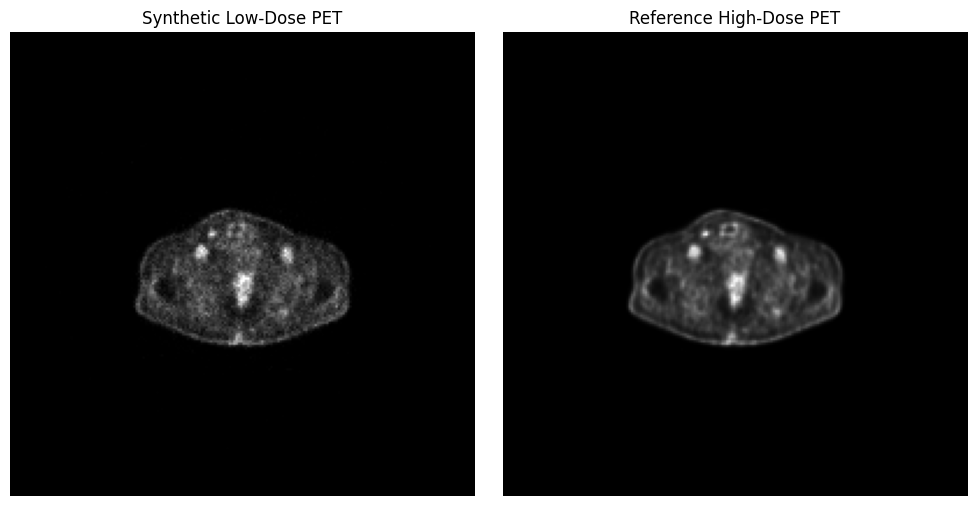


Using Device: cuda
Batch Size  : 4
✅ MONAI preprocessing enabled successfully!


In [2]:
#### CELL 2

!pip install -q monai

# =====================================================
# STEP 9: IMPORT REQUIRED LIBRARIES
# =====================================================

from torch.utils.data import Dataset, DataLoader
from monai.transforms import Compose, ScaleIntensity, EnsureType

# =====================================================
# STEP 10: DEFINE MONAI TRANSFORMS
# =====================================================

monai_transform = Compose([
    ScaleIntensity(),
    EnsureType()
])

# =====================================================
# STEP 11: CREATE CUSTOM PET DATASET
# =====================================================

class PETDataset(Dataset):

    def __init__(self, file_list):
        self.file_list = file_list

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):

        # -----------------------------
        # Load High-Dose PET Image
        # -----------------------------
        high_img = load_pet(self.file_list[idx])

        # -----------------------------
        # Generate Synthetic Low-Dose PET
        # -----------------------------
        low_img = simulate_low_dose(
            high_img,
            reduction_factor=10
        )

        # -----------------------------
        # Apply MONAI Preprocessing
        # -----------------------------
        high_img = monai_transform(high_img)
        low_img = monai_transform(low_img)

        # -----------------------------
        # Convert to PyTorch Tensors
        # -----------------------------
        high_img = torch.as_tensor(
            high_img,
            dtype=torch.float32
        ).unsqueeze(0)

        low_img = torch.as_tensor(
            low_img,
            dtype=torch.float32
        ).unsqueeze(0)

        return low_img, high_img

# =====================================================
# STEP 12: CREATE DATASETS
# =====================================================

train_dataset = PETDataset(train_files)
val_dataset = PETDataset(val_files)
test_dataset = PETDataset(test_files)

print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print("Training Samples   :", len(train_dataset))
print("Validation Samples :", len(val_dataset))
print("Testing Samples    :", len(test_dataset))

# =====================================================
# STEP 13: CREATE DATALOADERS
# =====================================================

BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\n✅ DataLoaders created successfully!")

# =====================================================
# STEP 14: VERIFY BATCH SHAPES
# =====================================================

low_batch, high_batch = next(iter(train_loader))

print("\nBatch Shapes")
print("Low Dose  :", low_batch.shape)
print("High Dose :", high_batch.shape)

# Expected output:
# Low Dose  : torch.Size([4, 1, H, W])
# High Dose : torch.Size([4, 1, H, W])

# =====================================================
# STEP 15: VISUALIZE ONE TRAINING SAMPLE
# =====================================================

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(low_batch[0, 0].cpu().numpy(), cmap="gray")
plt.title("Synthetic Low-Dose PET")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(high_batch[0, 0].cpu().numpy(), cmap="gray")
plt.title("Reference High-Dose PET")
plt.axis("off")

plt.tight_layout()
plt.show()

# =====================================================
# STEP 16: SET DEVICE
# =====================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\nUsing Device:", device)
print("Batch Size  :", BATCH_SIZE)
print("✅ MONAI preprocessing enabled successfully!")

In [3]:
### CELL 3


# =====================================================
# STEP 16: IMPORT REQUIRED LIBRARIES
# =====================================================

import torch
import torch.nn as nn
import torch.optim as optim

# =====================================================
# STEP 17: DEFINE U-NET MODEL
# =====================================================

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(1,64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64,128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128,256)
        self.pool3 = nn.MaxPool2d(2)

        self.bottom = DoubleConv(256,512)

        self.up3 = nn.ConvTranspose2d(512,256,2,stride=2)
        self.conv3 = DoubleConv(512,256)

        self.up2 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.conv2 = DoubleConv(256,128)

        self.up1 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.conv1 = DoubleConv(128,64)

        self.final = nn.Conv2d(64,1,1)

    def forward(self,x):

        c1=self.down1(x)
        p1=self.pool1(c1)

        c2=self.down2(p1)
        p2=self.pool2(c2)

        c3=self.down3(p2)
        p3=self.pool3(c3)

        b=self.bottom(p3)

        u3=self.up3(b)
        u3=torch.cat([u3,c3],dim=1)
        c4=self.conv3(u3)

        u2=self.up2(c4)
        u2=torch.cat([u2,c2],dim=1)
        c5=self.conv2(u2)

        u1=self.up1(c5)
        u1=torch.cat([u1,c1],dim=1)
        c6=self.conv1(u1)

        out=self.final(c6)

        return out

# =====================================================
# STEP 18: INITIALIZE MODEL
# =====================================================

model = UNet().to(device)

print("="*60)
print("U-NET MODEL INITIALIZED")
print("="*60)

# =====================================================
# STEP 19: DISPLAY MODEL INFORMATION
# =====================================================

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

# =====================================================
# STEP 20: LOSS FUNCTION
# =====================================================

criterion = nn.L1Loss()

print("Loss Function : L1 Loss")

# =====================================================
# STEP 21: OPTIMIZER
# =====================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Optimizer : Adam")

# =====================================================
# STEP 22: LR SCHEDULER
# =====================================================

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50
)

NUM_EPOCHS=50 #### epoch #######################################

print("="*60)
print("TRAINING CONFIGURATION")
print("="*60)
print("Epochs :",NUM_EPOCHS)
print("Learning Rate :",1e-4)
print("Batch Size :",BATCH_SIZE)
print("Device :",device)

U-NET MODEL INITIALIZED
Total Parameters     : 7,696,193
Trainable Parameters : 7,696,193
Loss Function : L1 Loss
Optimizer : Adam
TRAINING CONFIGURATION
Epochs : 50
Learning Rate : 0.0001
Batch Size : 4
Device : cuda


In [4]:
### CELL 4




# =====================================================
# STEP 25: IMPORT REQUIRED LIBRARIES
# =====================================================

from tqdm import tqdm
from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity
import numpy as np
import torch

# =====================================================
# STEP 26: INITIALIZE TRAINING VARIABLES
# =====================================================

best_loss = float("inf")

train_losses = []
val_losses = []

psnr_history = []
ssim_history = []

# =====================================================
# STEP 27: START TRAINING
# =====================================================

for epoch in range(NUM_EPOCHS):

    print("\n" + "=" * 60)
    print(f"Epoch [{epoch + 1}/{NUM_EPOCHS}]")
    print("=" * 60)

    # -------------------------------------------------
    # TRAINING PHASE
    # -------------------------------------------------

    model.train()

    running_loss = 0.0

    progress_bar = tqdm(train_loader)

    for low_img, high_img in progress_bar:

        low_img = low_img.to(device)
        high_img = high_img.to(device)

        optimizer.zero_grad()

        pred = model(low_img)

        loss = criterion(pred, high_img)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        progress_bar.set_postfix(
            Train_Loss=f"{loss.item():.6f}"
        )

    train_loss = running_loss / len(train_loader)

    train_losses.append(train_loss)

    # -------------------------------------------------
    # VALIDATION PHASE
    # -------------------------------------------------

    model.eval()

    val_running_loss = 0.0

    psnr_epoch = []
    ssim_epoch = []

    with torch.no_grad():

        for low_img, high_img in val_loader:

            low_img = low_img.to(device)
            high_img = high_img.to(device)

            pred = model(low_img)

            loss = criterion(pred, high_img)

            val_running_loss += loss.item()

            # -----------------------------------------
            # Compute metrics for each image in batch
            # -----------------------------------------

            batch_size = pred.shape[0]

            for i in range(batch_size):

                pred_np = pred[i, 0].cpu().numpy()
                gt_np = high_img[i, 0].cpu().numpy()

                pred_np = np.clip(pred_np, 0, 1)
                gt_np = np.clip(gt_np, 0, 1)

                psnr_epoch.append(
                    peak_signal_noise_ratio(
                        gt_np,
                        pred_np,
                        data_range=1.0
                    )
                )

                ssim_epoch.append(
                    structural_similarity(
                        gt_np,
                        pred_np,
                        data_range=1.0,
                        win_size=7
                    )
                )

    val_loss = val_running_loss / len(val_loader)

    val_losses.append(val_loss)

    avg_psnr = np.mean(psnr_epoch)
    avg_ssim = np.mean(ssim_epoch)

    psnr_history.append(avg_psnr)
    ssim_history.append(avg_ssim)

    scheduler.step()

    # -------------------------------------------------
    # PRINT RESULTS
    # -------------------------------------------------

    print(f"Training Loss   : {train_loss:.6f}")
    print(f"Validation Loss : {val_loss:.6f}")
    print(f"Validation PSNR : {avg_psnr:.4f}")
    print(f"Validation SSIM : {avg_ssim:.4f}")

    # -------------------------------------------------
    # SAVE BEST MODEL
    # -------------------------------------------------

    if val_loss < best_loss:

        best_loss = val_loss

        torch.save(
            model.state_dict(),
            "/kaggle/working/best_unet_pet.pth"
        )

        print("✅ Best model saved successfully!")

# =====================================================
# STEP 28: TRAINING COMPLETED
# =====================================================

print("\n" + "=" * 60)
print("TRAINING COMPLETED")
print("=" * 60)

print(f"Best Validation Loss : {best_loss:.6f}")
print("Saved Model          : /kaggle/working/best_unet_pet.pth")


Epoch [1/50]


100%|██████████| 298/298 [00:38<00:00,  7.70it/s, Train_Loss=0.002412]


Training Loss   : 0.005464
Validation Loss : 0.001892
Validation PSNR : 43.1080
Validation SSIM : 0.9923
✅ Best model saved successfully!

Epoch [2/50]


100%|██████████| 298/298 [00:39<00:00,  7.48it/s, Train_Loss=0.002917]


Training Loss   : 0.002051
Validation Loss : 0.002617
Validation PSNR : 43.4607
Validation SSIM : 0.9825

Epoch [3/50]


...

Training Loss   : 0.001447
Validation Loss : 0.001429
Validation PSNR : 44.5173
Validation SSIM : 0.9948
✅ Best model saved successfully!

Epoch [49/50]


100%|██████████| 298/298 [00:41<00:00,  7.15it/s, Train_Loss=0.001521]


Training Loss   : 0.001442
Validation Loss : 0.001446
Validation PSNR : 44.4229
Validation SSIM : 0.9947

Epoch [50/50]


100%|██████████| 298/298 [00:41<00:00,  7.20it/s, Train_Loss=0.001736]


Training Loss   : 0.001445
Validation Loss : 0.001434
Validation PSNR : 44.4966
Validation SSIM : 0.9947

TRAINING COMPLETED
Best Validation Loss : 0.001429
Saved Model          : /kaggle/working/best_unet_pet.pth


✅ Best U-Net model loaded successfully!


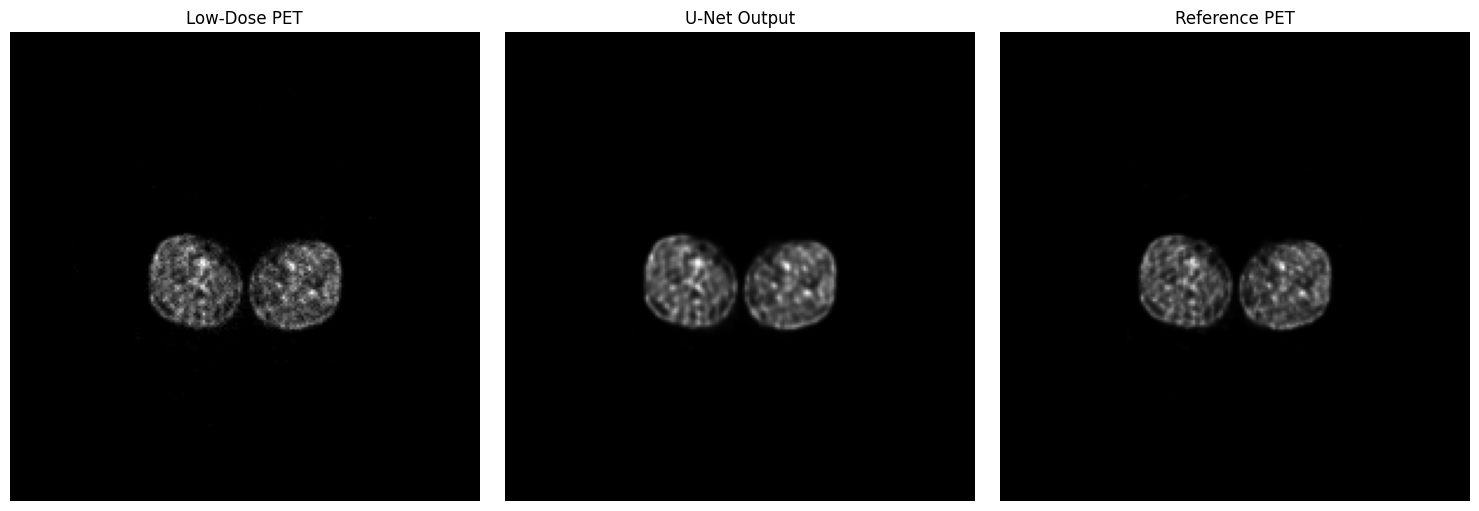

FINAL TEST RESULTS
Average PSNR  : 44.3521 dB
Average SSIM  : 0.9946
Average RMSE  : 0.006384
Average NRMSE : 0.006384


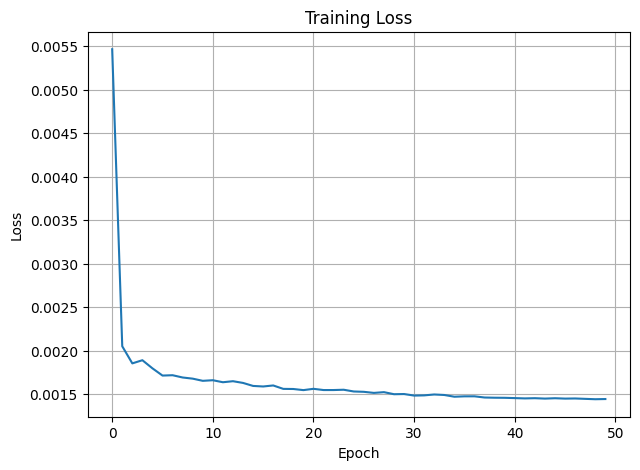

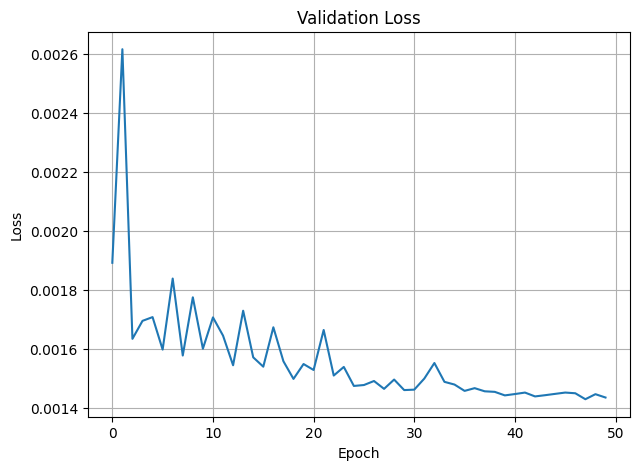

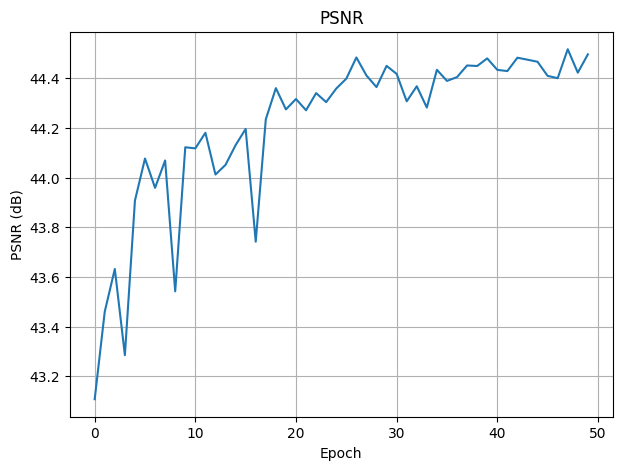

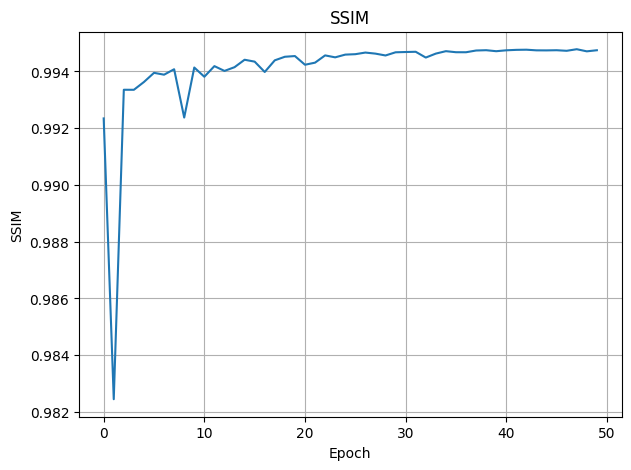


✅ PROJECT COMPLETED SUCCESSFULLY!


In [5]:
# =====================================================
# CELL 5: LOAD MODEL + EVALUATE U-NET
# =====================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import mean_squared_error
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# =====================================================
# LOAD TRAINED MODEL
# =====================================================

model_path = "/kaggle/working/best_unet_pet.pth"

if not os.path.exists(model_path):
    raise FileNotFoundError(
        f"Model not found!\n"
        f"Expected: {model_path}\n\n"
        f"Run the training cell (Cell 4) first."
    )

checkpoint = torch.load(model_path, map_location=device)

model.load_state_dict(checkpoint)
model.to(device)
model.eval()

print("✅ Best U-Net model loaded successfully!")

# =====================================================
# VISUALIZE ONE TEST SAMPLE
# =====================================================

low_img, high_img = next(iter(test_loader))

low_img = low_img.to(device)
high_img = high_img.to(device)

with torch.no_grad():
    restored = model(low_img)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(low_img[0,0].cpu().numpy(), cmap="gray")
plt.title("Low-Dose PET")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(restored[0,0].cpu().numpy(), cmap="gray")
plt.title("U-Net Output")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(high_img[0,0].cpu().numpy(), cmap="gray")
plt.title("Reference PET")
plt.axis("off")

plt.tight_layout()
plt.show()

# =====================================================
# EVALUATION
# =====================================================

psnr_list = []
ssim_list = []
rmse_list = []
nrmse_list = []

with torch.no_grad():

    for low_img, high_img in test_loader:

        low_img = low_img.to(device)
        high_img = high_img.to(device)

        pred = model(low_img)

        for i in range(pred.shape[0]):

            pred_np = pred[i,0].cpu().numpy()
            gt_np = high_img[i,0].cpu().numpy()

            pred_np = np.clip(np.nan_to_num(pred_np),0,1)
            gt_np = np.clip(np.nan_to_num(gt_np),0,1)

            psnr = peak_signal_noise_ratio(
                gt_np,
                pred_np,
                data_range=1.0
            )

            ssim = structural_similarity(
                gt_np,
                pred_np,
                data_range=1.0,
                win_size=7
            )

            mse = mean_squared_error(
                gt_np.flatten(),
                pred_np.flatten()
            )

            rmse = np.sqrt(mse)
            nrmse = rmse/(gt_np.max()-gt_np.min()+1e-8)

            psnr_list.append(psnr)
            ssim_list.append(ssim)
            rmse_list.append(rmse)
            nrmse_list.append(nrmse)

print("="*60)
print("FINAL TEST RESULTS")
print("="*60)

print(f"Average PSNR  : {np.mean(psnr_list):.4f} dB")
print(f"Average SSIM  : {np.mean(ssim_list):.4f}")
print(f"Average RMSE  : {np.mean(rmse_list):.6f}")
print(f"Average NRMSE : {np.mean(nrmse_list):.6f}")

# =====================================================
# TRAINING CURVES
# =====================================================

plt.figure(figsize=(7,5))
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(val_losses)
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(psnr_history)
plt.title("PSNR")
plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(ssim_history)
plt.title("SSIM")
plt.xlabel("Epoch")
plt.ylabel("SSIM")
plt.grid(True)
plt.show()

print("\n✅ PROJECT COMPLETED SUCCESSFULLY!")

In [6]:
# =====================================================
# CELL 6: SAVE PROJECT FILES
# =====================================================

import os
import shutil

save_dir = "/kaggle/working/project_results"
os.makedirs(save_dir, exist_ok=True)

# -----------------------------
# Copy trained model
# -----------------------------
model_path="/kaggle/working/best_unet_pet.pth"

if os.path.exists(model_path):
    shutil.copy(model_path, os.path.join(save_dir,"best_unet_pet.pth"))
    print("✅ Model copied.")
else:
    print("❌ Model file not found.")

# -----------------------------
# Save final metrics
# -----------------------------
with open(os.path.join(save_dir, "final_results.txt"), "w") as f:
    f.write("FINAL TEST RESULTS\n")
    f.write("=============================\n")
    f.write(f"Average PSNR  : {np.mean(psnr_list):.4f} dB\n")
    f.write(f"Average SSIM  : {np.mean(ssim_list):.4f}\n")
    f.write(f"Average RMSE  : {np.mean(rmse_list):.6f}\n")
    f.write(f"Average NRMSE : {np.mean(nrmse_list):.6f}\n")

print("✅ Metrics saved.")

# -----------------------------
# Save training loss graph
# -----------------------------
plt.figure(figsize=(7,5))
plt.plot(train_losses, marker="o")
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.savefig(os.path.join(save_dir, "training_loss.png"), dpi=300)
plt.close()

# -----------------------------
# Save validation loss graph
# -----------------------------
plt.figure(figsize=(7,5))
plt.plot(val_losses, marker="o")
plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.savefig(os.path.join(save_dir, "validation_loss.png"), dpi=300)
plt.close()

# -----------------------------
# Save PSNR graph
# -----------------------------
plt.figure(figsize=(7,5))
plt.plot(psnr_history, marker="o")
plt.title("PSNR vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("PSNR")
plt.grid(True)
plt.savefig(os.path.join(save_dir, "psnr_graph.png"), dpi=300)
plt.close()

# -----------------------------
# Save SSIM graph
# -----------------------------
plt.figure(figsize=(7,5))
plt.plot(ssim_history, marker="o")
plt.title("SSIM vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("SSIM")
plt.grid(True)
plt.savefig(os.path.join(save_dir, "ssim_graph.png"), dpi=300)
plt.close()

print("\n===================================")
print("✅ ALL FILES SAVED SUCCESSFULLY!")
print("===================================")
print("Saved folder:", save_dir)
print("\nFiles:")
print("- best_unet_pet.pth")
print("- final_results.txt")
print("- training_loss.png")
print("- validation_loss.png")
print("- psnr_graph.png")
print("- ssim_graph.png")

✅ Model copied.
✅ Metrics saved.

✅ ALL FILES SAVED SUCCESSFULLY!
Saved folder: /kaggle/working/project_results

Files:
- best_unet_pet.pth
- final_results.txt
- training_loss.png
- validation_loss.png
- psnr_graph.png
- ssim_graph.png
